# Libraries

In [1]:
# Libraries
import warnings
from datetime import datetime
import myFuncs
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
#from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn import set_config
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (AdaBoostRegressor, HistGradientBoostingRegressor,
                              RandomForestRegressor)
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (MinMaxScaler, OneHotEncoder,
                                   PolynomialFeatures, PowerTransformer,
                                   StandardScaler, TargetEncoder)
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from skopt import BayesSearchCV
from xgboost import XGBRegressor
import warnings
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_regression

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)


# Exploratoy Data Analysis

In [2]:
# import data
sample = pd.read_csv('datasets/sample.csv')

# head of data
sample.head()

,loc1,loc2,para1,dow,para2,para3,para4,price
0,0,01,1,Mon,662,3000.0,3.8,73.49
1,9,99,1,Thu,340,2760.0,9.2,300.00
2,0,04,0,Mon,16,2700.0,3.0,130.00
3,4,40,1,Mon,17,12320.0,6.4,365.00
4,5,50,1,Thu,610,2117.0,10.8,357.50


## Data Types of columns

In [3]:
# data types of columns
def df_datatypes(df):
    df_desc = pd.DataFrame(df.dtypes.value_counts().reset_index())
    df_desc.columns = ['Data Type', 'Count']
    return df_desc.sort_values('Count', ascending=False)

df_datatypes(sample)

,Data Type,Count
0,str,3
1,float64,3
2,int64,2


## Missing Data

In [4]:
# DataFrame info
myFuncs.df_missing_info(sample)

,Column,Data Type,Non-Null Count,# Null,Total Count,% Null
0,loc1,str,10000,0,10000,0.0%
1,loc2,str,10000,0,10000,0.0%
2,para1,int64,10000,0,10000,0.0%
3,dow,str,10000,0,10000,0.0%
4,para2,int64,10000,0,10000,0.0%
5,para3,float64,10000,0,10000,0.0%
6,para4,float64,10000,0,10000,0.0%
7,price,float64,10000,0,10000,0.0%


## Numerical Data

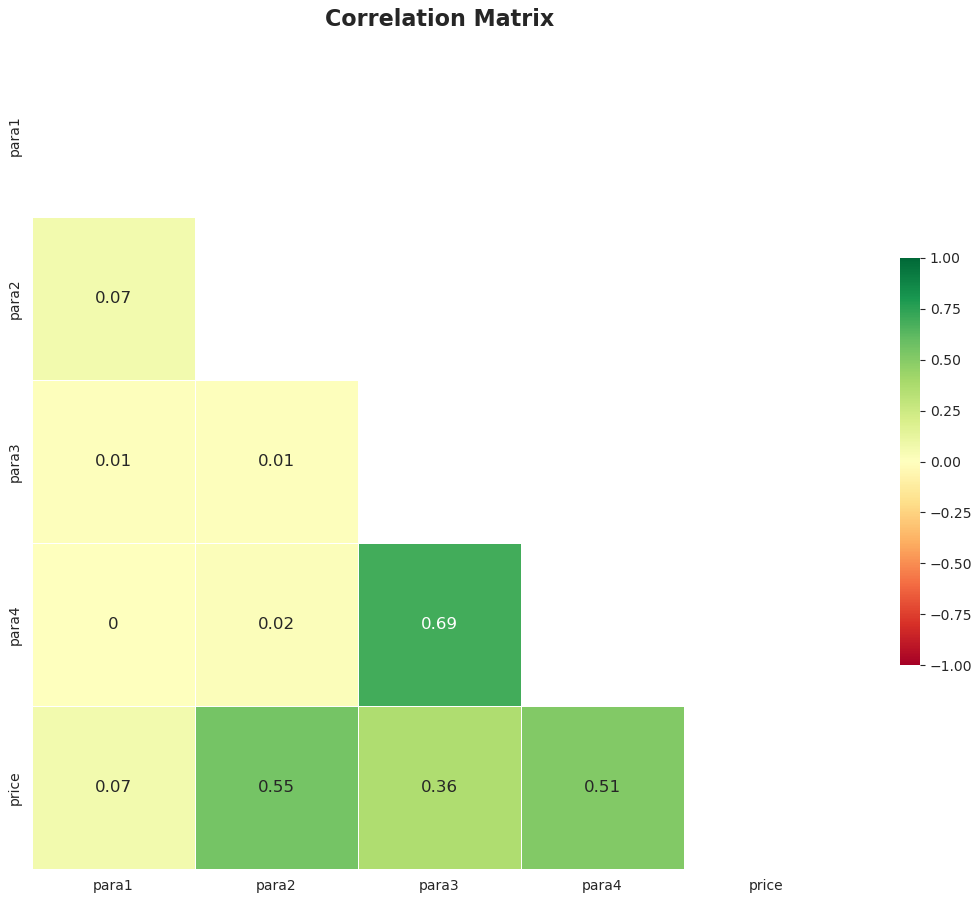

In [5]:
# numerical - correlogram
myFuncs.df_graph_correlogram(sample)
plt.show()

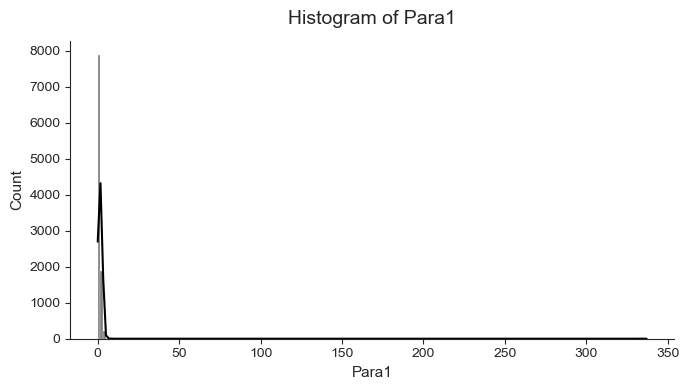

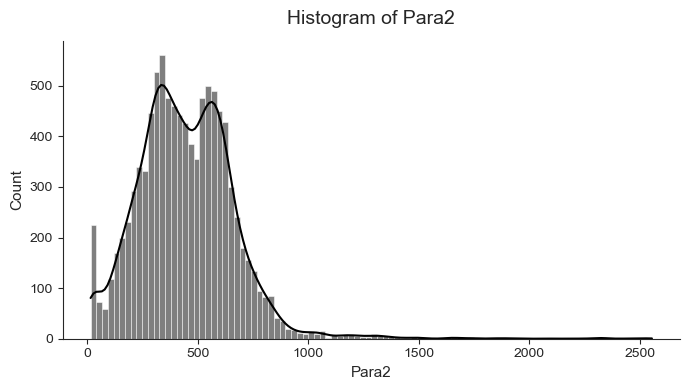

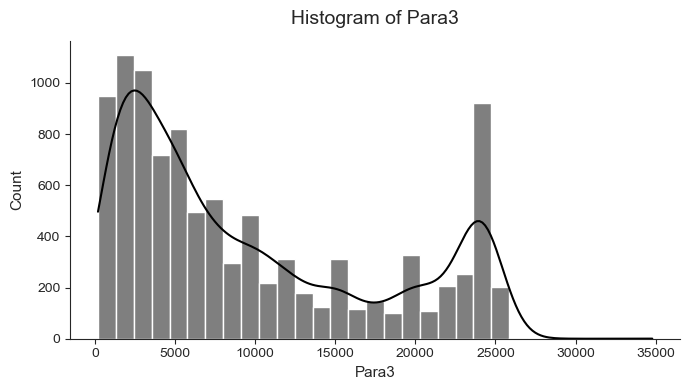

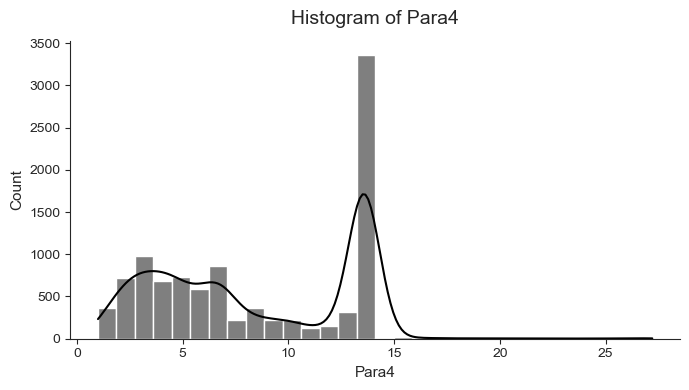

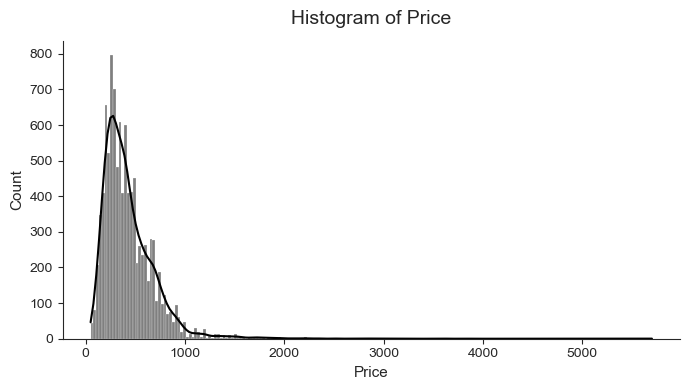

In [6]:
# graph of all numeric data types
myFuncs.df_graph_numeric_histograms(sample)

## Categorical Data

In [7]:
myFuncs.df_describe_categorical(sample)

,Column,Data Type,Count,Missing Values,Unique Values,Top Category,Top Category Frequency,% Top Category
0,loc1,str,10000,0,12,2,1607,16%
1,loc2,str,10000,0,107,21,499,5%
2,dow,str,10000,0,7,Wed,2233,22%


## ANOVA

In [8]:
myFuncs.df_get_anova(target='price', df=sample, is_target_cat=False, precision=4)

,Target,Source,ddof1,ddof2,F,p_unc,np2,S.S. Diff
0,price,loc1,11,9988,10.7295,0.0000,0.0117,Yes
1,price,loc2,106,9893,4.9445,0.0000,0.0503,Yes
2,price,dow,6,9993,3.5542,0.0016,0.0021,Yes


## Numeric Correlation with Price

In [9]:
# numeric correlation with price
pg.pairwise_corr(sample, columns=['price']).round(3)

,X,Y,method,alternative,n,r,CI95,p_unc,BF10,power
0,price,para1,pearson,two-sided,10000,0.075,"[0.06, 0.09]",0.0,1.827e+10,1.0
1,price,para2,pearson,two-sided,10000,0.553,"[0.54, 0.57]",0.0,inf,1.0
2,price,para3,pearson,two-sided,10000,0.355,"[0.34, 0.37]",0.0,4.369e+290,1.0
3,price,para4,pearson,two-sided,10000,0.515,"[0.5, 0.53]",0.0,inf,1.0


# Feature Importance

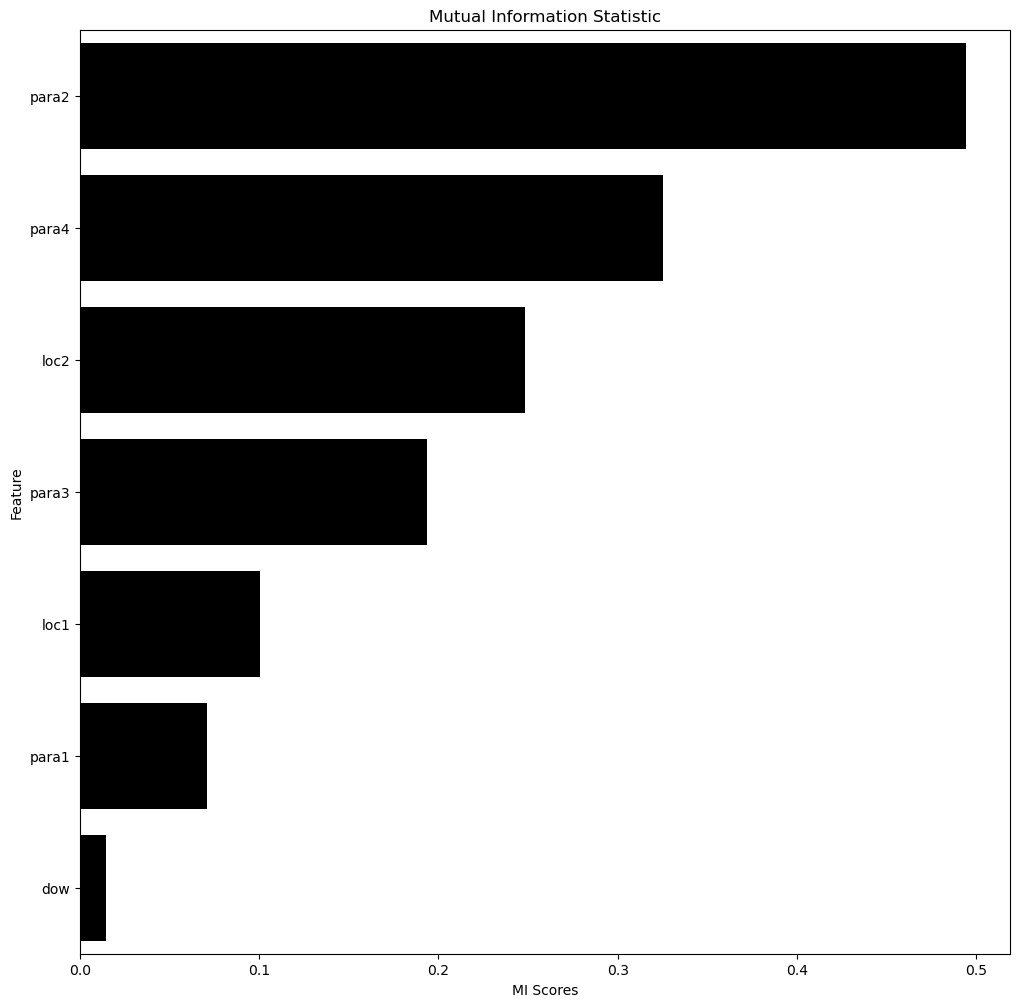

,Feature,MI Scores
4,para2,0.49417
6,para4,0.32553
1,loc2,0.24848
5,para3,0.19370
0,loc1,0.10041
3,para1,0.07085
2,dow,0.01437


In [10]:
# Split into X, y
x_data = sample.drop(columns='price')
y_data = sample['price']

myFuncs.mi_scores_regression(x_data, y_data)

# Model Setup

## Pipeline

In [11]:
# train, validation split
X_train, X_test, y_train, y_test = train_test_split(
    sample.drop('price', axis='columns'),
    sample['price'],
    test_size=0.30,
    random_state=2022
)

# select numeric_features
numeric_features = X_train.select_dtypes(include=np.number).columns.to_list()

# select categorical features
categorical_features = X_train.select_dtypes(exclude=np.number).columns.to_list()

In [12]:
# seperate high and lower cardinality features
n_unique_categories = X_train[categorical_features].nunique()
high_cardinality_features = n_unique_categories[n_unique_categories > 100].index
low_cardinality_features = n_unique_categories[n_unique_categories <= 100].index

In [13]:
myFuncs.df_describe_categorical(X_train[high_cardinality_features])

,Column,Data Type,Count,Missing Values,Unique Values,Top Category,Top Category Frequency,% Top Category
0,loc2,str,7000,0,105,21,363,5%


In [14]:
myFuncs.df_describe_categorical(X_train[low_cardinality_features])

,Column,Data Type,Count,Missing Values,Unique Values,Top Category,Top Category Frequency,% Top Category
0,loc1,str,7000,0,11,2,1154,16%
1,dow,str,7000,0,7,Wed,1540,22%


In [15]:

# Numeric Feature Pipeline
numeric_pipeline_steps = []
numeric_pipeline_steps.append(('min-max', MinMaxScaler(feature_range=(1, 2))))
numeric_pipeline_steps.append(('box-cox', PowerTransformer(method='box-cox')))
numeric_pipeline_steps.append(('poly', PolynomialFeatures(degree=2)))
numeric_pipeline = Pipeline(steps=numeric_pipeline_steps)

# Low Categorical Feature Pipeline
low_categorical_pipeline_steps = []
low_categorical_pipeline_steps.append(('onehot', OneHotEncoder(handle_unknown='ignore')))
low_categorical_pipeline = Pipeline(steps=low_categorical_pipeline_steps)

# High Categorical Feature Pipeline
high_categorical_pipeline_steps = []
high_categorical_pipeline_steps.append(('targetEncoder', TargetEncoder(target_type='continuous')))
high_categorical_pipeline = Pipeline(steps=high_categorical_pipeline_steps)

# Preprocessing Transformer
transformer_steps = []
transformer_steps.append(('low_cat', low_categorical_pipeline, low_cardinality_features))
transformer_steps.append(('high_cat', high_categorical_pipeline, high_cardinality_features))
transformer_steps.append(('num', numeric_pipeline, numeric_features))
preprocessing_transformer = ColumnTransformer(transformers=transformer_steps)

# target pipeline (min-max, box-cox)
target_pipeline_steps = []
target_pipeline_steps.append(('min-max', MinMaxScaler(feature_range=(1,2))))
target_pipeline_steps.append(('boxcox', PowerTransformer(method=('box-cox'))))
target_pipeline = Pipeline(steps=target_pipeline_steps)

In [16]:
# Display Transformer for features
set_config(display='diagram')
preprocessing_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('low_cat', ...), ('high_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [17]:
# Display Transformer for target
set_config(display='diagram')
target_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('min-max', ...), ('boxcox', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(1, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'box-cox'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normalization to thetransformed output.",True
,"copy copy: bool, default=TrueSet to False to perform inplace computation during transformation.",True


## Models

In [18]:
# Models
models = []
models.append(('AB-C', AdaBoostRegressor(random_state=2022)))
#models.append(('CBR', CatBoostRegressor(iterations=1000, loss_function='RMSE', random_state=2022)))
models.append(('EN', ElasticNet()))
models.append(('KNN', KNeighborsRegressor(weights='distance')))
models.append(('Lasso', Lasso()))
models.append(('RF', RandomForestRegressor(random_state=2022)))
models.append(('DR', DummyRegressor(strategy="mean")))
models.append(('DTR', DecisionTreeRegressor()))

# Spot Check Models

In [19]:
# result df
results = pd.DataFrame()

# scoring metric
scoring = 'neg_root_mean_squared_error'

# cv
cv = KFold(n_splits=10, shuffle=True, random_state=2022)

for name, model in models:
    # Pipeline
    model_pipeline_steps = []
    model_pipeline_steps.append(('transformer', preprocessing_transformer))
    model_pipeline_steps.append(('model', model))
    model_pipeline = Pipeline(steps=model_pipeline_steps)
    transformed_model = TransformedTargetRegressor(
        regressor=model_pipeline, transformer=target_pipeline)
    # CV results
    cv_results = cross_val_score(
        transformed_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    abs_cv_results = pd.Series(cv_results).abs()
    temp_df = pd.DataFrame({name: abs_cv_results})
    results = pd.concat([results, temp_df], axis='columns')
    # Mean +/- std
    msg = f'{name}: {abs_cv_results.mean().round(5)} +/- {abs_cv_results.std().round(5)}'
    print(msg)

AB-C: 199.45365 +/- 27.74156
EN: 270.46276 +/- 27.19572
KNN: 160.51166 +/- 19.3358
Lasso: 278.45883 +/- 26.79036
RF: 153.8129 +/- 22.88309
DR: 278.45883 +/- 26.79036
DTR: 206.51314 +/- 20.79209


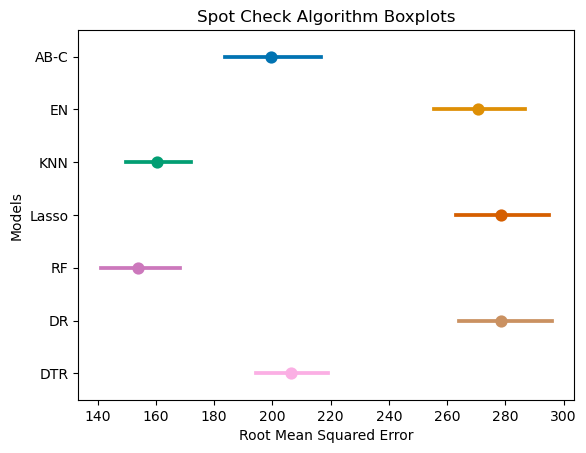

In [20]:
# Algorithm Comparison Boxplot
sns.pointplot(y='model', x=scoring,
            data=pd.melt(results, var_name='model', value_name=scoring), palette='colorblind')
plt.title('Spot Check Algorithm Boxplots')
plt.ylabel('Models')
plt.xlabel('Root Mean Squared Error')
plt.show()

In [21]:
# dataframe of folds with results
pd.set_option('display.max_rows', results.shape[0])
results

,AB-C,EN,KNN,Lasso,RF,DR,DTR
0,193.025113,264.361892,160.976603,272.979891,146.396443,272.979891,189.321368
1,169.987450,249.157891,138.845616,257.845340,125.511519,257.845340,181.642676
2,190.455389,266.133522,152.673507,274.661531,140.351605,274.661531,197.655594
3,257.641209,323.641436,204.261716,330.612323,202.930340,330.612323,236.713950
4,221.889430,297.158539,177.129946,305.041630,174.822178,305.041630,210.774705
5,169.689280,239.471234,140.549385,247.519451,143.317735,247.519451,210.751489
6,188.205088,248.931193,161.023826,257.187158,152.892052,257.187158,202.549680
7,181.629704,246.718726,145.158703,254.553270,134.153718,254.553270,178.796534
8,225.999311,295.074691,163.483921,302.352812,170.557156,302.352812,238.526127
9,196.014479,273.978486,161.013331,281.834940,147.196212,281.834940,218.399305


In [22]:
# dataframe of model averages and standard deviations
pd.DataFrame({
    'mean':results.mean(),
    'std':results.std()
    }).sort_values('mean', ascending=True)

,mean,std
RF,153.812896,22.883089
KNN,160.511655,19.335802
AB-C,199.453645,27.741563
DTR,206.513143,20.792087
EN,270.462761,27.195723
Lasso,278.458835,26.790363
DR,278.458835,26.790363


# Tuning Best Model

In [23]:
# Model
tuning_model = KNeighborsRegressor(weights='distance')

# Scoring
scoring = 'neg_root_mean_squared_error'

# Pipeline Steps
model_pipeline_steps = []
model_pipeline_steps.append(('transformer', preprocessing_transformer))
model_pipeline_steps.append(('model', tuning_model))
model_pipeline = Pipeline(steps=model_pipeline_steps)

# Tranform Target
transformed_model = TransformedTargetRegressor(
    regressor=model_pipeline,
    transformer=PowerTransformer(method='box-cox'))

# Param Grid
transformed_model.get_params()
param_grid = {
    'regressor__model__n_neighbors': np.arange(start=1,stop=30,step=2)
}

# RandomizedSearchCV
bs_model = BayesSearchCV(
    estimator=transformed_model,
    search_spaces=param_grid,
    scoring=scoring,
	n_iter=50,
    n_jobs=-1
)

# Display Model
bs_model

,estimator,TransformedTa...od='box-cox'))
,search_spaces,"{'regressor__model__n_neighbors': array([ 1, 3..., 25, 27, 29])}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,optimizer_kwargs,None
,n_iter,50
,fit_params,None
,n_points,1
,iid,'deprecated'
,refit,True
,cv,None


In [24]:
# Fit Model on Train
bs_model.fit(X_train, y_train)

,estimator,TransformedTa...od='box-cox'))
,search_spaces,"{'regressor__model__n_neighbors': array([ 1, 3..., 25, 27, 29])}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,optimizer_kwargs,None
,n_iter,50
,fit_params,None
,n_points,1
,iid,'deprecated'
,refit,True
,cv,None


In [26]:
myFuncs.display_model_best_params(bs_model.best_params_)

           🎯 Best Model Hyperparameters           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Parameter                     ┃ Optimized Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ regressor__model__n_neighbors │               9 │
└───────────────────────────────┴─────────────────┘

In [27]:
# best score
print(f'best score: {abs(bs_model.best_score_).round(5)}')

best score: 157.69334


In [28]:
# best model
transformed_final_model = bs_model.best_estimator_

In [29]:
# RMSE on Test Set
test_rmse = root_mean_squared_error(y_test, transformed_final_model.predict(X_test))
rounded_test_rmse = np.round(test_rmse,5)
print(f'RMSE on Test Set: {rounded_test_rmse}')

RMSE on Test Set: 176.56772


In [30]:
# Save Model
model_name = 'KNN'
model_file_name = f'models/{model_name} on {datetime.now().strftime("%Y %b %d at %H.%M.%S")}.pkl'
joblib.dump(transformed_final_model, model_file_name)

['models/KNN on 2026 Jul 09 at 14.51.21.pkl']